# =================================================================
# PROJECT: PHOSPHORUS REGRESSION MODEL (Virtual Sensor)
# OBJECTIVE: Predict Ptot using real-time sensor data
# =================================================================


--- PRECISE PREDICTION SAMPLES (LAST 10 RECORDS) ---
      Date and Time  Actual Ptot [µg/l]  Predicted Ptot [µg/l]  Difference   Error %
2021-11-04 02:30:00                35.0              32.496667    2.503333  7.152381
2021-11-04 03:00:00                37.0              32.870000    4.130000 11.162162
2021-11-04 03:30:00                36.0              31.838333    4.161667 11.560185
2021-11-04 04:00:00                35.0              31.940000    3.060000  8.742857
2021-11-04 04:30:00                35.0              31.910000    3.090000  8.828571
2021-11-04 05:00:00                35.0              31.778333    3.221667  9.204762
2021-11-04 05:30:00                35.0              31.688333    3.311667  9.461905
2021-11-04 06:00:00                41.0              31.688333    9.311667 22.711382
2021-11-04 06:30:00                38.0              31.818333    6.181667 16.267544
2021-11-04 07:00:00                37.0              31.325000    5.675000 15.337838


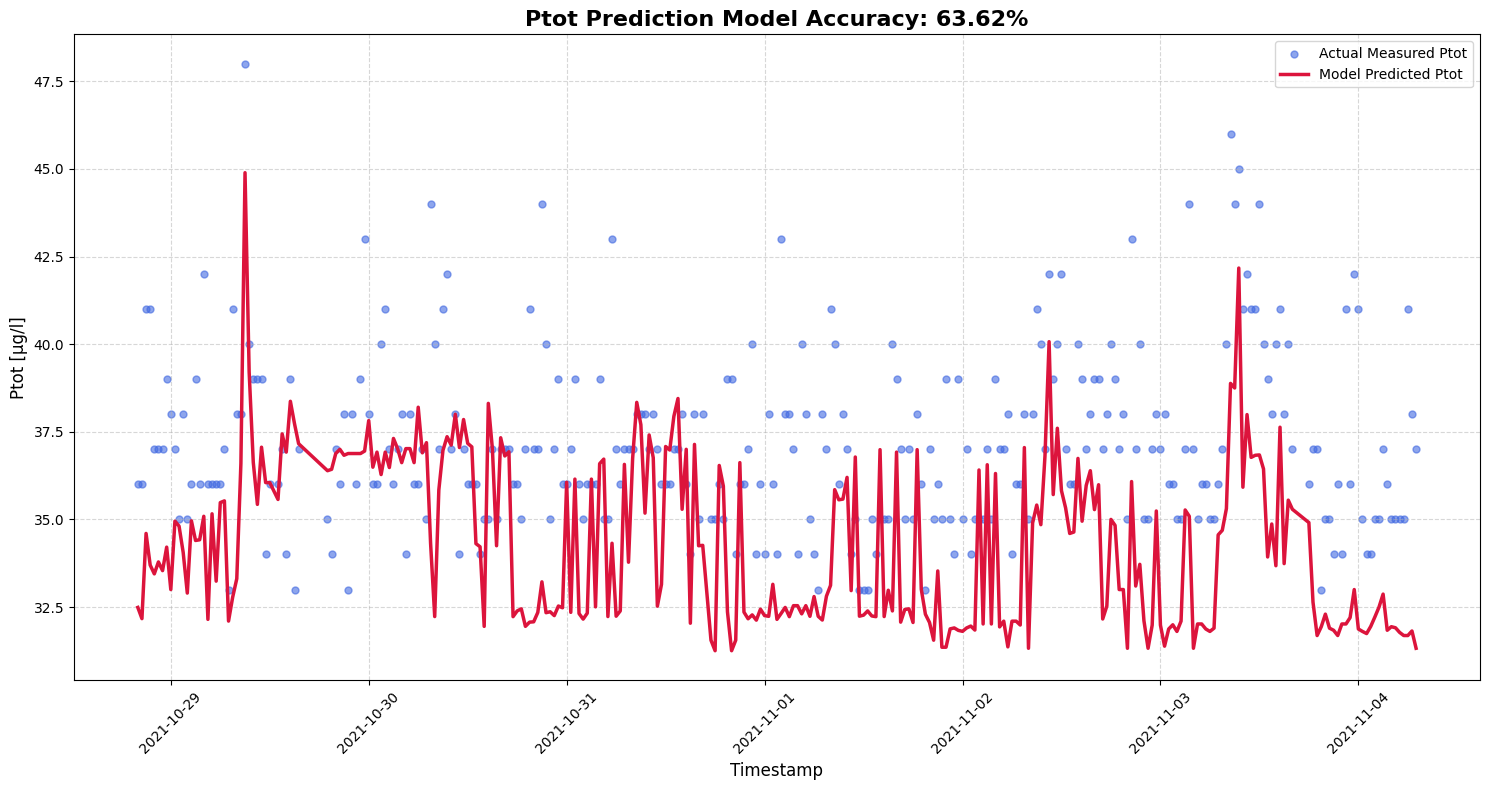

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# --- 1. DATA LOADING & PRE-PROCESSING ---
# Loading the Kuonanjoki dataset with Finnish formatting
df = pd.read_csv('kuonanjoki_data.csv', sep=';', decimal=',')

# Convert Date and Time for chronological sorting and display
df['date and time'] = pd.to_datetime(df['date and time'], format='%d.%m.%Y %H:%M')
df = df.sort_values('date and time')

# Define target: Total Phosphorus (Ptot)
# Define features: The physical sensors (Temperature, Flow, Turbidity, etc.)
target = 'Ptot [µg/l]'
features = [
    'Water temperature [°C]', 'Conductivitiy [µS/cm]', 'Oxygen [mg/l]',
    'Turbidity [FNU]', 'Suspended solids [mg/l]', 'Velocity [cm/s]', 'Discharge [l/s]'
]

# Drop missing values to ensure the model only trains on verified sensor readings
df_clean = df.dropna(subset=features + [target]).copy()

# --- 2. MACHINE LEARNING WORKFLOW ---
X = df_clean[features]
y = df_clean[target]

# We use a chronological split: the last 20% of the historical data is for testing
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_clean['date and time'].iloc[split_idx:]

# Train the Random Forest Regressor
# This model identifies non-linear patterns between flow and nutrient loading
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 3. PRECISE VALUE COMPARISON (OUTPUT TEXT) ---
# Generate predictions for the test set
y_pred = model.predict(X_test)

# Create a comparison table to show precise values
comparison_df = pd.DataFrame({
    'Date and Time': dates_test,
    'Actual Ptot [µg/l]': y_test,
    'Predicted Ptot [µg/l]': y_pred
})

# Calculate precise accuracy metrics for each point
comparison_df['Difference'] = comparison_df['Actual Ptot [µg/l]'] - comparison_df['Predicted Ptot [µg/l]']
comparison_df['Error %'] = (abs(comparison_df['Difference']) / comparison_df['Actual Ptot [µg/l]']) * 100

print("\n--- PRECISE PREDICTION SAMPLES (LAST 10 RECORDS) ---")
print(comparison_df.tail(10).to_string(index=False))

# --- 4. FINAL VISUALIZATION ---
# Zooming in to see the last 300 data points clearly
zoom = 300
plt.figure(figsize=(15, 8))

# Actual values as blue dots
plt.scatter(dates_test.iloc[-zoom:], y_test.iloc[-zoom:], 
            color='royalblue', label='Actual Measured Ptot', s=25, alpha=0.6)

# Predicted values as a red trend line
plt.plot(dates_test.iloc[-zoom:], y_pred[-zoom:], 
         color='crimson', label='Model Predicted Ptot', linewidth=2.5)

# Formatting
r2 = r2_score(y_test, y_pred)
plt.title(f'Ptot Prediction Model Accuracy: {r2:.2%}', fontsize=16, fontweight='bold')
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Ptot [µg/l]', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('ptot_prediction_results.png')
plt.show()